# 채용 플랫폼 Quality User 행동 분석
## — Retention · URL · 프로필 통합 리포트

---

> **분석 기간**: 2022-01-01 ~ 2023-12-31  
> **최종 작성일**: 2025-06


# 1. 프로젝트 개요

## 1.1 분석 배경

채용 플랫폼의 핵심 가치는 단순 방문자를 실제 구직 활동을 수행하는 **"질 좋은 유저(Quality User)"** 로 전환하고, 이들이 지속적으로 플랫폼을 사용하도록 유지하는 것이다.

본 분석은 MySQL 기반의 서버 행동 로그(`log_2022`, `log_2023`)와 지원 이력 테이블(`Application`, `JobBookmark`)을 활용하여, 팀원 4명이 URL 카테고리를 분담해 분석한 결과를 하나의 보고서로 통합한 것이다.

## 1.2 분석 목적

"어떤 행동이 좋은 유저를 만드는가?"와 "좋은 유저는 어떤 경로로 서비스에 정착하는가?"를 이해하기 위한 행동 분석이다.

## 1.3 질 좋은 유저(Quality User) 정의

| 조건 | 기준 |
|------|------|
| 가입 완료 | `signup/detail` → `step1` → `step2` → `step3/done(200)` 순서 통과 |
| 실제 지원 | 가입 완료 이후 `Application` 테이블에 1건 이상 지원 기록 존재 |
| Retention | 첫 지원 이후 **24시간 초과** 시점에 주요 URL 재방문 |

## 1.4 핵심 분석 질문

1. 질 좋은 유저는 어떤 행동을 하는가?  
2. 첫 지원 이후 어떤 행동이 재방문 및 추가 지원으로 이어지는가?  
3. Retention 유저는 일반 유저와 무엇이 다른가?  
4. 지원 프로세스에서 이탈과 전환은 어디서 발생하는가?  
5. 지원 완료 이후 어떤 행동이 서비스 재이용으로 이어지는가?



---
# 2. 데이터 및 환경 설정

## 2.1 데이터 설명

| 테이블 | 설명 |
|--------|------|
| `log_2022`, `log_2023` | 서버 행동 로그. user_uuid, timestamp, URL, response_code, method 포함 |
| `logs_preprocessed_fast` | 공통 전처리가 완료된 로그 테이블 (최초 1회 생성 후 재사용) |
| `Application` | 지원 이력. user_uuid, job_uuid, company_uuid, cdate 포함 |
| `JobBookmark` | 북마크 이력. user_uuid, job_uuid, cdate 포함 |
| `Company` | 기업 정보 테이블 |

분석 기간은 2022-01-01 ~ 2023-12-31이며, response_code 400/404/500 및 1초 이내 중복 로그는 제거된 상태를 기준으로 한다.

## 2.2 라이브러리 로드


In [1]:
# =========================
# 2.2 라이브러리 로드
# =========================
!pip install pymysql sqlalchemy plotly koreanize-matplotlib pyarrow adjustText -q

import os
import re
import warnings
import logging

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import koreanize_matplotlib

import plotly.express as px
import plotly.graph_objects as go

from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

print("라이브러리 로드 완료")


라이브러리 로드 완료


## 2.3 공통 설정

In [2]:
# =========================
# 2.3 공통 설정
# =========================

# 한글 폰트 (OS별 자동 적용)
plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

px.defaults.template = "plotly_white"

print("공통 설정 완료")


공통 설정 완료


## 2.4 데이터 로딩 (DB 연결 및 캐시)

In [3]:
# =========================
# 2.4-1. DB 연결
# =========================
# 접속 정보는 코드에 두지 않는다. 저장소 루트의 .env 에서 읽어온다.
# 최초 1회: .env.example 를 .env 로 복사한 뒤 RECRUIT_DB_URL 을 채울 것.
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(usecwd=True))
engine = create_engine(os.environ["RECRUIT_DB_URL"])

print("DB 연결 완료")


DB 연결 완료


In [4]:
# =========================
# 2.4-2. Parquet 캐시 설정
# =========================
# 시간이 오래 걸리는 쿼리 결과를 ./cache/*.parquet에 저장해 재실행 시 빠르게 로드한다.
# REFRESH_CACHE = True 로 설정하면 캐시를 무시하고 DB에서 새로 실행한다.

CACHE_DIR = "./_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
REFRESH_CACHE = False   # True: 캐시 무시하고 재생성


def cache_path(name):
    return os.path.join(CACHE_DIR, f"{name}.parquet")


def cache_exists(name, required_cols=None):
    path = cache_path(name)
    if not os.path.exists(path):
        return False
    if required_cols is None:
        return True
    try:
        import pyarrow.parquet as pq
        schema_cols = set(pq.read_schema(path).names)
        return set(required_cols).issubset(schema_cols)
    except Exception:
        return False


def clean_for_parquet(df):
    """object 컬럼의 혼합 타입을 정리하여 parquet 저장 가능하게 만든다."""
    df = df.copy()
    for col in df.columns:
        s = df[col]
        if isinstance(s.dtype, pd.CategoricalDtype):
            df[col] = s.astype("string")
            continue
        if isinstance(s.dtype, pd.DatetimeTZDtype):
            df[col] = s.dt.tz_localize(None)
            continue
        if s.dtype == "object":
            non_null = s.dropna()
            if len(non_null) == 0:
                df[col] = s.astype("string")
            elif non_null.map(lambda x: isinstance(x, (bool, np.bool_))).all():
                df[col] = s.astype("boolean")
            elif non_null.map(lambda x: isinstance(x, (int, float, np.integer, np.floating, bool, np.bool_))).all():
                df[col] = s.map(lambda x: int(x) if isinstance(x, (bool, np.bool_)) else x)
                df[col] = pd.to_numeric(df[col], errors="coerce")
            else:
                df[col] = s.astype("string")
    return df


def save_cache(df, name):
    path = cache_path(name)
    clean_for_parquet(df).to_parquet(path, index=False)
    print(f"캐시 저장: {path} / shape={df.shape}")


def load_cache(name):
    path = cache_path(name)
    df = pd.read_parquet(path)
    print(f"캐시 로드: {path} / shape={df.shape}")
    return df


def fix_datetime_cols(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
            if isinstance(df[col].dtype, pd.DatetimeTZDtype):
                df[col] = df[col].dt.tz_localize(None)
    return df


print("캐시 설정 완료:", CACHE_DIR)


캐시 설정 완료: ./_cache


---
# 3. 분석 대상 정의

## 3.1 공통 로그 전처리 (`logs_preprocessed_fast`)

원본 로그 테이블(`log_2022`, `log_2023`)은 용량이 매우 크기 때문에, 분석 초반에 공통 전처리 기준을 적용한 `logs_preprocessed_fast` 테이블을 한 번 생성하고 이후 모든 분석에서 재사용한다.

**전처리 기준**
- `user_uuid` 없는 로그 제거
- timestamp 결측 및 분석 기간 외 로그 제거 (2022-01-01 ~ 2023-12-31)
- response_code 400, 404, 500 제거
- 1000자 이상 URL 제거
- 동일 유저의 동일 URL/method/response_code가 1초 이내 반복된 경우 중복 제거
- `:uuid,`, `none`, `null`, `undefined` 계열 이상 URL 제거


In [5]:
# =========================
# 3.1 전처리 테이블 존재 여부 확인
# =========================

def table_exists(table_name, engine):
    query = f"""
    SELECT COUNT(*) AS cnt
    FROM information_schema.tables
    WHERE table_schema = DATABASE()
      AND table_name = '{table_name}';
    """
    return pd.read_sql(query, engine)["cnt"].iloc[0] > 0


logs_preprocessed_exists = table_exists("logs_preprocessed_fast", engine)
print("logs_preprocessed_fast 존재 여부:", logs_preprocessed_exists)


logs_preprocessed_fast 존재 여부: True


In [6]:
# =========================
# 3.1-1. 전처리 테이블 생성 (없을 경우에만 실행)
# =========================
REBUILD_PREPROCESSED = False   # True로 바꾸면 강제 재생성

if logs_preprocessed_exists and not REBUILD_PREPROCESSED:
    print("logs_preprocessed_fast 이미 존재. 전처리 생략.")
    preprocess_check = pd.read_sql("""
    SELECT COUNT(*) AS log_count, COUNT(DISTINCT user_uuid) AS user_count,
           MIN(timestamp) AS min_ts, MAX(timestamp) AS max_ts
    FROM logs_preprocessed_fast;
    """, engine)
    display(preprocess_check)

else:
    print("logs_preprocessed_fast 새로 생성합니다...")
    with engine.begin() as conn:
        conn.exec_driver_sql("DROP TABLE IF EXISTS logs_preprocessed_fast;")
        conn.exec_driver_sql("DROP TABLE IF EXISTS logs_preprocessed_stage;")

        # 1단계: 기본 클린 로그
        conn.exec_driver_sql("""
        CREATE TABLE logs_preprocessed_stage AS
        WITH raw_logs AS (
            SELECT user_uuid, timestamp, URL, response_code, method FROM log_2022
            UNION ALL
            SELECT user_uuid, timestamp, URL, response_code, method FROM log_2023
        ),
        typed_logs AS (
            SELECT
                TRIM(CAST(user_uuid AS CHAR)) AS user_uuid,
                COALESCE(
                    STR_TO_DATE(REPLACE(TRIM(CAST(timestamp AS CHAR)), ' UTC', ''), '%%Y-%%m-%%d %%H:%%i:%%s.%%f'),
                    STR_TO_DATE(REPLACE(TRIM(CAST(timestamp AS CHAR)), ' UTC', ''), '%%Y-%%m-%%d %%H:%%i:%%s')
                ) AS timestamp,
                TRIM(CAST(URL AS CHAR)) AS URL,
                CASE WHEN CAST(response_code AS CHAR) REGEXP '^[0-9]+$'
                     THEN CAST(response_code AS UNSIGNED) ELSE NULL END AS response_code,
                UPPER(TRIM(CAST(method AS CHAR))) AS method,
                LOWER(TRIM(BOTH '/' FROM SUBSTRING_INDEX(SUBSTRING_INDEX(TRIM(CAST(URL AS CHAR)), '?', 1), '#', 1))) AS url_path,
                MD5(TRIM(CAST(URL AS CHAR))) AS url_hash
            FROM raw_logs
        )
        SELECT user_uuid, timestamp, URL, response_code, method, url_path, url_hash
        FROM typed_logs
        WHERE user_uuid IS NOT NULL AND user_uuid <> ''
          AND timestamp IS NOT NULL AND timestamp >= '2022-01-01' AND timestamp < '2024-01-01'
          AND URL IS NOT NULL AND URL <> '' AND CHAR_LENGTH(URL) <= 1000
          AND method IS NOT NULL AND method IN ('GET','POST','PUT','DELETE','PATCH','HEAD','OPTIONS')
          AND response_code IS NOT NULL AND response_code NOT IN (400, 404, 500);
        """)

        conn.exec_driver_sql("""
        ALTER TABLE logs_preprocessed_stage
            ADD INDEX idx_stage_user_time (user_uuid, timestamp),
            ADD INDEX idx_stage_path (url_path(191));
        """)

        # 2단계: 이상 URL 제거 + 중복 제거
        conn.exec_driver_sql("""
        CREATE TABLE logs_preprocessed_fast AS
        WITH filtered AS (
            SELECT * FROM logs_preprocessed_stage
            WHERE url_path IS NOT NULL AND url_path <> ''
              AND url_path NOT LIKE ':uuid,%%'
              AND url_path NOT IN ('none', 'r', 'api')
              AND url_path NOT LIKE '%%undefined%%'
              AND url_path NOT REGEXP '(^|/|,)null($|/|,)'
        ),
        dedup AS (
            SELECT *, LAG(timestamp) OVER (
                PARTITION BY user_uuid, url_hash, method, response_code ORDER BY timestamp
            ) AS prev_same_log_time
            FROM filtered
        )
        SELECT user_uuid, timestamp, URL, response_code, method, url_path, url_hash
        FROM dedup
        WHERE prev_same_log_time IS NULL
           OR TIMESTAMPDIFF(SECOND, prev_same_log_time, timestamp) > 1;
        """)

        conn.exec_driver_sql("""
        ALTER TABLE logs_preprocessed_fast
            ADD INDEX idx_lpf_user_time (user_uuid, timestamp),
            ADD INDEX idx_lpf_path (url_path(191)),
            ADD INDEX idx_lpf_hash (url_hash);
        """)

    print("logs_preprocessed_fast 생성 완료")


logs_preprocessed_fast 이미 존재. 전처리 생략.


## 3.2 가입 완료 유저 정의 (공통 CTE)

In [7]:
# =========================
# 3.2 가입 완료 유저 공통 CTE 문자열 정의
# =========================
# signup/detail → step1 → step2 → step3/done(200) 순서를 모두 통과한 유저.
# 이 CTE는 이후 모든 분석 쿼리에서 WITH절 앞에 붙여 사용한다.

signup_cte = """
WITH logs AS (
    SELECT user_uuid, timestamp, URL, response_code, method, url_path
    FROM logs_preprocessed_fast
),
step_detail_users AS (
    SELECT user_uuid, MIN(timestamp) AS detail_time
    FROM logs WHERE url_path LIKE 'signup/detail%%' GROUP BY user_uuid
),
step1_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d ON l.user_uuid = d.user_uuid AND l.timestamp >= d.detail_time
    WHERE l.url_path LIKE 'signup/step1%%' GROUP BY l.user_uuid
),
step2_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1 ON l.user_uuid = s1.user_uuid AND l.timestamp >= s1.step1_time
    WHERE l.url_path LIKE 'signup/step2%%' GROUP BY l.user_uuid
),
step3_done_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS done_time
    FROM logs l
    INNER JOIN step2_users s2 ON l.user_uuid = s2.user_uuid AND l.timestamp >= s2.step2_time
    WHERE l.url_path LIKE 'signup/step3/done%%' AND l.response_code = 200
    GROUP BY l.user_uuid
)
"""

print("가입 완료 CTE 정의 완료")


가입 완료 CTE 정의 완료


## 3.3 Retention 유저 정의

**Retention 기준**: 가입 완료 후 지원까지 완료한 유저 중, 첫 지원 시점으로부터 **24시간 초과** 이후에 주요 URL(상위 30% 이상 이용 URL)을 재방문한 유저.


In [8]:
# =========================
# 3.3-1. url_log_df 생성 또는 캐시 로드
# =========================
# 분석 기준 DataFrame: 가입 완료 유저 중 지원 이력이 있는 유저의 전체 로그
# (signup 로그 제외, api/timeline 제외)

CACHE_NAME = "url_log_df"
REQUIRED_COLS = ["user_uuid", "timestamp", "URL", "response_code", "method",
                 "url_path", "done_time", "first_apply_time", "apply_total",
                 "apply_job_cnt", "first_bm_time", "bm_cnt"]

if cache_exists(CACHE_NAME, required_cols=REQUIRED_COLS) and not REFRESH_CACHE:
    url_log_df = load_cache(CACHE_NAME)
else:
    query = """
    WITH logs AS (
        SELECT user_uuid, timestamp, URL, response_code, method, url_path
        FROM logs_preprocessed_fast
    ),
    step_detail_users AS (
        SELECT user_uuid, MIN(timestamp) AS detail_time FROM logs
        WHERE url_path LIKE 'signup/detail%%' GROUP BY user_uuid
    ),
    step1_users AS (
        SELECT l.user_uuid, MIN(l.timestamp) AS step1_time FROM logs l
        INNER JOIN step_detail_users d ON l.user_uuid=d.user_uuid AND l.timestamp>=d.detail_time
        WHERE l.url_path LIKE 'signup/step1%%' GROUP BY l.user_uuid
    ),
    step2_users AS (
        SELECT l.user_uuid, MIN(l.timestamp) AS step2_time FROM logs l
        INNER JOIN step1_users s1 ON l.user_uuid=s1.user_uuid AND l.timestamp>=s1.step1_time
        WHERE l.url_path LIKE 'signup/step2%%' GROUP BY l.user_uuid
    ),
    step3_done_users AS (
        SELECT l.user_uuid, MIN(l.timestamp) AS done_time FROM logs l
        INNER JOIN step2_users s2 ON l.user_uuid=s2.user_uuid AND l.timestamp>=s2.step2_time
        WHERE l.url_path LIKE 'signup/step3/done%%' AND l.response_code=200
        GROUP BY l.user_uuid
    ),
    bookmark_users AS (
        SELECT d.user_uuid, MIN(jb.cdate) AS first_bm_time, COUNT(DISTINCT jb.job_uuid) AS bm_cnt
        FROM step3_done_users d
        INNER JOIN JobBookmark jb ON d.user_uuid=jb.user_uuid AND jb.cdate>=d.done_time
        GROUP BY d.user_uuid
    ),
    first_apply_users AS (
        SELECT d.user_uuid, MIN(a.cdate) AS first_apply_time,
               COUNT(*) AS apply_total, COUNT(DISTINCT a.job_uuid) AS apply_job_cnt
        FROM step3_done_users d
        INNER JOIN Application a ON d.user_uuid=a.user_uuid AND a.cdate>=d.done_time
        GROUP BY d.user_uuid
    )
    SELECT l.user_uuid, l.timestamp, l.URL, l.response_code, l.method, l.url_path,
           d.done_time, fa.first_apply_time, fa.apply_total, fa.apply_job_cnt,
           bu.first_bm_time, COALESCE(bu.bm_cnt, 0) AS bm_cnt
    FROM logs l
    INNER JOIN step3_done_users d ON l.user_uuid=d.user_uuid AND l.timestamp>=d.done_time
    INNER JOIN first_apply_users fa ON l.user_uuid=fa.user_uuid
    LEFT JOIN bookmark_users bu ON l.user_uuid=bu.user_uuid
    WHERE l.URL IS NOT NULL AND TRIM(l.URL)<>''
      AND l.url_path NOT LIKE '%%signup%%'
      AND l.url_path <> 'api/timeline';
    """
    url_log_df = pd.read_sql(query, engine)
    save_cache(url_log_df, CACHE_NAME)

url_log_df = fix_datetime_cols(url_log_df,
    ["timestamp", "done_time", "first_apply_time", "first_bm_time"])

print(f"url_log_df shape: {url_log_df.shape}")
# (데이터 보호: 원본 미리보기 출력 제거)
# url_log_df.head(3)


캐시 로드: ./_cache\url_log_df.parquet / shape=(3949741, 13)


url_log_df shape: (3949741, 13)


In [9]:
# =========================
# 3.3-2. URL 정규화 함수
# =========================

def normalize_url(url):
    """URL의 동적 ID 부분을 정규화된 패턴으로 치환한다."""
    if pd.isna(url):
        return "NULL_URL"
    url = str(url).strip().lower().strip("/")
    if url == "":
        return "NULL_URL"

    # 유저 페이지
    if re.match(r"^@[^/]+/applications", url):   return "@user_id/applications"
    if re.match(r"^@[^/]+/bookmark", url):        return "@user_id/bookmark"
    if re.match(r"^@[^/]+/resume", url):          return "@user_id/resume"
    if re.match(r"^@[^/]+/job_offer/received", url): return "@user_id/job_offer/received"
    if re.match(r"^@[^/]+/job_offer/sent", url):  return "@user_id/job_offer/sent"
    if re.match(r"^@[^/]+$", url):                return "@user_id"

    # 지원 절차
    if re.match(r"^jobs/[0-9]+/apply/step1", url):    return "jobs/id/apply/step1"
    if re.match(r"^jobs/[0-9]+/apply/step2", url):    return "jobs/id/apply/step2"
    if re.match(r"^jobs/[0-9]+/apply/step3", url):    return "jobs/id/apply/step3"
    if re.match(r"^jobs/[0-9]+/apply/step4", url):    return "jobs/id/apply/step4"
    if re.match(r"^jobs/[0-9]+/apply/complete", url): return "jobs/id/apply/complete"
    if re.match(r"^jobs/[0-9]+/applications", url):   return "jobs/id/applications"
    if re.match(r"^jobs/[0-9]+/[^/]+$", url):        return "jobs/id/id_title"
    if re.match(r"^jobs/[0-9]+$", url):               return "jobs/id"

    if re.match(r"^api/jobs/[0-9]+/apply/step1", url): return "api/jobs/id/apply/step1"
    if re.match(r"^api/jobs/[0-9]+/apply/step2", url): return "api/jobs/id/apply/step2"
    if re.match(r"^api/jobs/[0-9]+/apply/step3", url): return "api/jobs/id/apply/step3"
    if re.match(r"^api/jobs/[0-9]+/apply/step4", url): return "api/jobs/id/apply/step4"
    if re.match(r"^api/jobs/[0-9]+/bookmark", url):   return "api/jobs/id/bookmark"
    if re.match(r"^api/jobs/[0-9]+/other_jobs", url): return "api/jobs/id/other_jobs"
    if re.match(r"^api/jobs/[0-9]+", url):            return "api/jobs/id"

    # 회사 탐색
    if re.match(r"^companies/[^/]+/jobs", url):  return "companies/company_id/jobs"
    if re.match(r"^companies/[^/]+$", url):       return "companies/company_id"
    if re.match(r"^api/companies/[^/]+", url):    return "api/companies/id"

    # 유저 프로필
    if re.match(r"^api/users/[^/]+/career", url):    return "api/users/id/career"
    if re.match(r"^api/users/[^/]+/project", url):   return "api/users/id/project"
    if re.match(r"^api/users/[^/]+/education", url): return "api/users/id/education"
    if re.match(r"^api/users/[^/]+", url):           return "api/users/id"

    # 오퍼
    if re.match(r"^api/job_offer/[^/]+/modal", url):   return "api/job_offer/id/modal"
    if re.match(r"^api/job_offer/[^/]+/reject/template", url): return "api/job_offer/id/reject/template"
    if re.match(r"^api/job_offer/[^/]+/reject", url):  return "api/job_offer/id/reject"

    # 기타
    if url.startswith("api/apply_progress"):          return "api/apply_progress"
    if re.match(r"^api/remove_application/[0-9]+", url): return "api/remove_application/id"
    if url.startswith("api/jobs/job_title"):          return "api/jobs/job_title"
    if url.startswith("api/search/companies"):        return "api/search/companies"
    if url.startswith("suggest"):                     return "suggest"
    if url.startswith("search"):                      return "search"
    return url


url_log_df["normalized_url"] = url_log_df["url_path"].apply(normalize_url)
print("URL 정규화 완료")
url_log_df[["url_path", "normalized_url"]].drop_duplicates().head(10)


URL 정규화 완료


In [10]:
# =========================
# 3.3-3. Retention 유저 정의 및 집계
# =========================
# 리텐션 판단 기준: 상위 30%ile 이상 이용 URL 중 하나를
# 첫 지원 시점 + 24시간 이후에 방문한 유저

CACHE_NAME = "retention_users"

if cache_exists(CACHE_NAME) and not REFRESH_CACHE:
    retention_users = load_cache(CACHE_NAME)
    retention_users = fix_datetime_cols(retention_users, ["first_retention_time"])
else:
    # 리텐션 기준 URL: user_count 상위 30%ile 이상
    refined_category = (
        url_log_df
        .groupby("normalized_url", as_index=False)
        .agg(log_count=("user_uuid", "count"), user_count=("user_uuid", "nunique"))
        .rename(columns={"normalized_url": "url"})
    )
    url_lower = refined_category["url"].astype(str).str.lower()
    remove_cond = (
        url_lower.str.startswith(":uuid,") |
        url_lower.isin(["null_url", "none", "r", "api"]) |
        url_lower.str.contains("undefined", na=False) |
        url_lower.str.contains(r"(^|/|,)null($|/|,)", regex=True, na=False) |
        url_lower.str.contains("signup", na=False)
    )
    refined_clean = refined_category[~remove_cond].copy()
    threshold = refined_clean["user_count"].quantile(0.70)
    top_urls = set(refined_clean[refined_clean["user_count"] >= threshold]["url"])

    RETENTION_GAP = pd.Timedelta(hours=24)
    valid_df = url_log_df.dropna(subset=["user_uuid","timestamp","first_apply_time","normalized_url"]).copy()
    after_apply_logs = valid_df[
        (valid_df["timestamp"] >= valid_df["first_apply_time"] + RETENTION_GAP) &
        (valid_df["normalized_url"].isin(top_urls))
    ].copy()

    retention_users = (
        after_apply_logs
        .groupby("user_uuid", as_index=False)
        .agg(first_retention_time=("timestamp", "min"),
             retention_log_count=("normalized_url", "count"),
             retention_url_count=("normalized_url", "nunique"))
    )
    save_cache(retention_users, CACHE_NAME)
    retention_users = fix_datetime_cols(retention_users, ["first_retention_time"])

# 요약
base_apply_users = (
    url_log_df[["user_uuid","done_time","first_apply_time","apply_total","apply_job_cnt","first_bm_time","bm_cnt"]]
    .drop_duplicates(subset=["user_uuid"]).copy()
)
retention_result = base_apply_users.merge(retention_users, on="user_uuid", how="left")
retention_result["is_retained"] = retention_result["first_retention_time"].notna()

print(f"가입+지원 완료 유저: {base_apply_users['user_uuid'].nunique():,}명")
print(f"Retention 유저:     {retention_result['is_retained'].sum():,}명")
print(f"Retention율:        {retention_result['is_retained'].mean()*100:.1f}%")


캐시 로드: ./_cache\retention_users.parquet / shape=(3791, 4)
가입+지원 완료 유저: 4,077명
Retention 유저:     3,791명
Retention율:        93.0%


---
# 4. URL 분류 체계 구축

## 4.1 카테고리 정의

팀원 분담에 따라 URL을 12개 카테고리로 분류한다.


In [11]:
# =========================
# 4.1 URL 카테고리 매핑 정의
# =========================

url_category_map = {
    # 01_가입/온보딩
    "signup/detail": "01_가입/온보딩",
    "signup/step1": "01_가입/온보딩",
    "signup/step2": "01_가입/온보딩",
    "signup/step3": "01_가입/온보딩",

    # 02_공고 검색/필터
    "jobs": "02_공고 검색/필터",
    "api/jobs/job_title": "02_공고 검색/필터",
    "api/search": "02_공고 검색/필터",
    "suggest": "02_공고 검색/필터",
    "search": "02_공고 검색/필터",

    # 03_공고 상세/추천
    "jobs/id": "03_공고 상세/추천",
    "jobs/id/id_title": "03_공고 상세/추천",
    "api/jobs/id": "03_공고 상세/추천",
    "api/jobs/id/other_jobs": "03_공고 상세/추천",
    "api/jobs/id/bookmark": "03_공고 상세/추천",

    # 04_회사 탐색
    "companies": "04_회사 탐색",
    "companies/company_id": "04_회사 탐색",
    "companies/company_id/jobs": "04_회사 탐색",
    "api/companies/id": "04_회사 탐색",
    "api/search/companies": "04_회사 탐색",

    # 05_프로필/이력서
    "@user_id": "05_프로필/이력서",
    "@user_id/resume": "05_프로필/이력서",
    "@user_id/applications": "05_프로필/이력서",
    "@user_id/bookmark": "05_프로필/이력서",
    "api/users/id": "05_프로필/이력서",
    "api/users/id/career": "05_프로필/이력서",
    "api/users/id/project": "05_프로필/이력서",
    "api/users/id/education": "05_프로필/이력서",

    # 06_지원 절차
    "jobs/id/apply/step1": "06_지원 절차",
    "jobs/id/apply/step2": "06_지원 절차",
    "jobs/id/apply/step3": "06_지원 절차",
    "jobs/id/apply/step4": "06_지원 절차",
    "jobs/id/apply/complete": "06_지원 절차",
    "api/jobs/id/apply/step1": "06_지원 절차",
    "api/jobs/id/apply/step2": "06_지원 절차",
    "api/jobs/id/apply/step3": "06_지원 절차",
    "api/jobs/id/apply/step4": "06_지원 절차",

    # 07_지원 후 관리
    "api/apply_progress": "07_지원 후 관리",
    "jobs/id/applications": "07_지원 후 관리",
    "api/remove_application/id": "07_지원 후 관리",

    # 08_저장/관심표시
    "api/jobs/id/bookmark": "08_저장/관심표시",

    # 09_오퍼
    "@user_id/job_offer/received": "09_오퍼",
    "@user_id/job_offer/sent": "09_오퍼",
    "api/job_offer/id/modal": "09_오퍼",
    "api/job_offer/id/reject": "09_오퍼",
    "api/job_offer/id/reject/template": "09_오퍼",

    # 11_사람/네트워크
    "people": "11_사람/네트워크",
    "api/search/people/job_title": "11_사람/네트워크",
    "api/search/people/major": "11_사람/네트워크",
    "api/search/people/schools": "11_사람/네트워크",
    "api/search/users": "11_사람/네트워크",
}

url_log_df["category"] = url_log_df["normalized_url"].map(url_category_map)
mapping_rate = url_log_df["category"].notna().mean() * 100
print(f"카테고리 매핑률: {mapping_rate:.1f}%")
url_log_df[["normalized_url","category"]].drop_duplicates().dropna().head(20)


카테고리 매핑률: 82.3%


## 4.2 URL 서브카테고리 정의

In [12]:
# =========================
# 4.2 URL 서브카테고리 정의 (회사탐색 / 오퍼 / 사람·네트워크)
# =========================

company_url_map = {
    "api/search/companies": "회사 검색",
    "companies": "회사 리스트",
    "companies/company_id": "회사 상세",
    "api/companies/id": "회사 상세",
    "companies/company_id/jobs": "회사 공고",
}

offer_url_map = {
    "@user_id/job_offer/received": "받은 오퍼",
    "@user_id/job_offer/sent": "보낸 오퍼",
    "api/job_offer/id/modal": "오퍼 상세",
    "api/job_offer/id/reject": "오퍼 거절",
    "api/job_offer/id/reject/template": "오퍼 거절 작성",
}

people_url_map = {
    "people": "허브 메인",
    "api/search/people/job_title": "직군별 사람 찾기",
    "api/search/people/major": "전공별 사람 찾기",
    "api/search/people/schools": "학교별 사람 찾기",
    "api/search/users": "사용자 직접 검색",
    "@user_id/following": "팔로잉",
    "@user_id/follower": "팔로워",
    "@user_id/likes": "좋아요",
    "@user_id/blockings": "차단",
    "api/relationship_nodes/modal/id/user/id/id": "인맥 관계망",
}

# 프로필/이력서 서브카테고리
profile_url_map = {
    "@user_id/resume": "이력서 조회",
    "api/users/id/career": "경력 조회",
    "api/users/id/project": "프로젝트 조회",
    "api/users/id/education": "학력 조회",
    "api/project/form_data/media": "포트폴리오 강화",
    "api/verify/experience/id/form": "경력검증 강화",
}

feature_url_map = {}
feature_url_map.update(company_url_map)
feature_url_map.update(offer_url_map)
feature_url_map.update(people_url_map)
feature_url_map.update(profile_url_map)

url_log_df["feature_subcategory"] = url_log_df["normalized_url"].map(feature_url_map)

print("서브카테고리 매핑 완료")
url_log_df[["normalized_url","category","feature_subcategory"]].drop_duplicates().dropna().head(15)


서브카테고리 매핑 완료


## 4.3 분류 결과 검증

In [13]:
# =========================
# 4.3 카테고리별 로그 수 확인
# =========================

category_summary = (
    url_log_df.groupby("category", dropna=False)
    .agg(log_count=("user_uuid", "count"), user_count=("user_uuid", "nunique"))
    .sort_values("user_count", ascending=False)
)

fig = px.bar(
    category_summary.reset_index(),
    x="category",
    y="user_count",
    text="user_count",
    title="카테고리별 이용 유저 수",
    labels={"category": "카테고리", "user_count": "유저 수"},
    height=450
)
fig.update_traces(texttemplate="%{text:,}", textposition="outside")
fig.update_layout(xaxis_tickangle=-30)
fig.show()

category_summary


---
# 5. 가입 퍼널 분석

## 5.1 가입 단계별 퍼널

가입 프로세스를 `signup/detail` → `step1` → `step2` → `step3/done(200)` 4단계로 정의하고, 각 단계별 도달 유저 수와 이탈률을 측정한다.


In [14]:
# =========================
# 5.1 가입 퍼널 집계
# =========================

query = signup_cte + """
SELECT
    (SELECT COUNT(DISTINCT user_uuid) FROM step_detail_users) AS detail_users,
    (SELECT COUNT(DISTINCT user_uuid) FROM step1_users) AS step1_users,
    (SELECT COUNT(DISTINCT user_uuid) FROM step2_users) AS step2_users,
    (SELECT COUNT(DISTINCT user_uuid) FROM step3_done_users) AS done_users;
"""

signup_funnel_raw = pd.read_sql(query, engine)

signup_funnel = pd.DataFrame({
    "stage": ["detail 진입", "step1 진입", "step2 진입", "가입 완료"],
    "user_count": [
        signup_funnel_raw.loc[0, "detail_users"],
        signup_funnel_raw.loc[0, "step1_users"],
        signup_funnel_raw.loc[0, "step2_users"],
        signup_funnel_raw.loc[0, "done_users"],
    ]
})
signup_funnel["conversion_from_first"] = (signup_funnel["user_count"] / signup_funnel.loc[0, "user_count"] * 100).round(1)
signup_funnel["dropoff_from_prev"] = (100 - (signup_funnel["user_count"] / signup_funnel["user_count"].shift(1) * 100)).round(1)
signup_funnel.loc[0, "dropoff_from_prev"] = 0

signup_funnel


In [15]:
# =========================
# 5.1 가입 퍼널 시각화
# =========================

fig = go.Figure(go.Funnel(
    y=signup_funnel["stage"],
    x=signup_funnel["user_count"],
    textinfo="value+percent initial+percent previous",
    marker={"line": {"width": 1}}
))
fig.update_layout(title="회원가입 퍼널 (단계별 전환율)", height=500, font=dict(size=13))
fig.show()


### 해석

- **step1 → step2 이탈**이 가장 큰 이탈 구간으로, 기본 정보 입력 이후 경력/학력 작성에서 다수 이탈함을 의미한다.
- **step2 → step3/done** 구간은 비교적 이탈이 낮아, step2까지 진행한 유저의 완주율이 높다.
- 가입 퍼널에서 이탈을 줄이기 위해서는 step1/step2 단계 UX 개선이 우선 과제다.


## 5.2 가입 단계 세부 분석

In [16]:
# =========================
# 5.2 세부 단계별 URL 행동 패턴
# =========================

signup_url_pattern = pd.read_sql("""
SELECT url_path, method, response_code,
       COUNT(*) AS log_count, COUNT(DISTINCT user_uuid) AS user_count
FROM logs_preprocessed_fast
WHERE url_path LIKE 'signup%%' OR url_path LIKE 'api/signup%%'
GROUP BY url_path, method, response_code
ORDER BY user_count DESC, log_count DESC
LIMIT 30;
""", engine)

fig = px.bar(
    signup_url_pattern.head(20).sort_values("user_count"),
    x="user_count", y="url_path", orientation="h", text="user_count",
    title="Signup 세부 URL별 유저 수 TOP 20",
    labels={"user_count": "유저 수", "url_path": "URL path"},
    height=600
)
fig.update_traces(texttemplate="%{text:,}", textposition="outside")
fig.show()

signup_url_pattern.head(20)


## 5.3 월별 가입 퍼널 추이

In [17]:
# =========================
# 5.3 월별 가입 퍼널 추이
# =========================

query = signup_cte + """
SELECT month,
       SUM(detail_users) AS detail_users, SUM(step1_users) AS step1_users,
       SUM(step2_users) AS step2_users, SUM(done_users) AS done_users
FROM (
    SELECT DATE_FORMAT(detail_time, '%%Y-%%m') AS month,
           COUNT(DISTINCT user_uuid) AS detail_users, 0 AS step1_users, 0 AS step2_users, 0 AS done_users
    FROM step_detail_users GROUP BY DATE_FORMAT(detail_time, '%%Y-%%m')
    UNION ALL
    SELECT DATE_FORMAT(step1_time, '%%Y-%%m'), 0, COUNT(DISTINCT user_uuid), 0, 0
    FROM step1_users GROUP BY DATE_FORMAT(step1_time, '%%Y-%%m')
    UNION ALL
    SELECT DATE_FORMAT(step2_time, '%%Y-%%m'), 0, 0, COUNT(DISTINCT user_uuid), 0
    FROM step2_users GROUP BY DATE_FORMAT(step2_time, '%%Y-%%m')
    UNION ALL
    SELECT DATE_FORMAT(done_time, '%%Y-%%m'), 0, 0, 0, COUNT(DISTINCT user_uuid)
    FROM step3_done_users GROUP BY DATE_FORMAT(done_time, '%%Y-%%m')
) t
WHERE month IS NOT NULL
GROUP BY month ORDER BY month;
"""

monthly_funnel = pd.read_sql(query, engine)
monthly_long = monthly_funnel.melt(
    id_vars=["month"],
    value_vars=["detail_users", "step1_users", "step2_users", "done_users"],
    var_name="stage", value_name="user_count"
)
monthly_long["stage"] = monthly_long["stage"].map({
    "detail_users": "detail 진입", "step1_users": "step1 진입",
    "step2_users": "step2 진입", "done_users": "가입 완료"
})

fig = px.line(monthly_long, x="month", y="user_count", color="stage", markers=True,
              title="월별 회원가입 퍼널 추이", height=500)
fig.show()


---
# 6. Retention 분석

## 6.1 Classic Retention (첫 지원 기준 100일)

**Classic Retention**: Day N에 재방문한 유저 수 / 기준 코호트 유저 수.  
기준 코호트는 첫 지원 완료 유저이며, Day 0은 첫 지원 당일이다.


In [18]:
# =========================
# 6.1 Classic Retention 100일
# =========================

CACHE_NAME = "classic_retention_100d"

if cache_exists(CACHE_NAME) and not REFRESH_CACHE:
    classic_retention_100d = load_cache(CACHE_NAME)
else:
    MAX_DAY = 100
    cohort_users_set = set(retention_users["user_uuid"].unique())
    base_n = len(cohort_users_set)

    refined_category = (
        url_log_df.groupby("normalized_url", as_index=False)
        .agg(log_count=("user_uuid","count"), user_count=("user_uuid","nunique"))
        .rename(columns={"normalized_url": "url"})
    )
    url_lower = refined_category["url"].astype(str).str.lower()
    remove_cond = (url_lower.str.startswith(":uuid,") | url_lower.isin(["null_url","none","r","api"]) |
                   url_lower.str.contains("undefined", na=False) |
                   url_lower.str.contains(r"(^|/|,)null($|/|,)", regex=True, na=False) |
                   url_lower.str.contains("signup", na=False))
    refined_clean = refined_category[~remove_cond].copy()
    threshold = refined_clean["user_count"].quantile(0.70)
    top_urls = set(refined_clean[refined_clean["user_count"] >= threshold]["url"])

    classic_base_df = url_log_df[url_log_df["user_uuid"].isin(cohort_users_set)].dropna(
        subset=["timestamp","first_apply_time","normalized_url"]).copy()
    classic_base_df["days_after_first_apply"] = (
        classic_base_df["timestamp"] - classic_base_df["first_apply_time"]
    ).dt.total_seconds() / 86400
    classic_base_df["retention_day"] = np.floor(classic_base_df["days_after_first_apply"]).astype("Int64")

    classic_event_df = classic_base_df[
        (classic_base_df["retention_day"] >= 1) &
        (classic_base_df["retention_day"] <= MAX_DAY) &
        (classic_base_df["normalized_url"].isin(top_urls))
    ].copy()

    classic_ret = (
        classic_event_df.drop_duplicates(["user_uuid","retention_day"])
        .groupby("retention_day", as_index=False)
        .agg(retained_users=("user_uuid","nunique"))
    )
    all_days = pd.DataFrame({"retention_day": range(1, MAX_DAY+1)})
    classic_retention_100d = all_days.merge(classic_ret, on="retention_day", how="left")
    classic_retention_100d["retained_users"] = classic_retention_100d["retained_users"].fillna(0).astype(int)
    classic_retention_100d["base_users"] = base_n
    classic_retention_100d["retention_rate"] = (classic_retention_100d["retained_users"] / base_n * 100).round(2)
    save_cache(classic_retention_100d, CACHE_NAME)

fig = px.line(classic_retention_100d, x="retention_day", y="retention_rate",
              markers=False, title="Classic Retention (첫 지원 기준 100일)",
              labels={"retention_day": "첫 지원 이후 일차", "retention_rate": "리텐션율 (%)"},
              height=520)
fig.update_layout(yaxis_ticksuffix="%")
fig.show()


캐시 로드: ./_cache\classic_retention_100d.parquet / shape=(100, 4)


In [19]:
# 주요 일차 Classic Retention
target_days = [1, 3, 7, 10, 14, 30, 60, 90, 100]
classic_selected = classic_retention_100d[classic_retention_100d["retention_day"].isin(target_days)].copy()

fig = px.bar(classic_selected, x="retention_day", y="retention_rate", text="retention_rate",
             title="주요 일차 Classic Retention",
             labels={"retention_day": "일차", "retention_rate": "리텐션율 (%)"},
             height=450)
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig.update_layout(yaxis_ticksuffix="%")
fig.show()

classic_selected


### 해석

- Day 1 리텐션이 가장 높으며, 이후 빠르게 감소하는 일반적인 리텐션 곡선 형태를 보인다.
- Day 7~14 구간의 기울기 변화가 주목 포인트로, 첫 주 이내에 재방문 습관이 형성된 유저가 장기 Retention으로 이어질 가능성이 높다.


## 6.2 Rolling Retention (첫 지원 기준 100일)

In [20]:
# =========================
# 6.2 Rolling Retention 100일
# =========================

CACHE_NAME = "rolling_retention_100d"

if cache_exists(CACHE_NAME) and not REFRESH_CACHE:
    rolling_retention_100d = load_cache(CACHE_NAME)
else:
    MAX_DAY = 100
    cohort_users_set = set(retention_users["user_uuid"].unique())
    base_n = len(cohort_users_set)

    # classic_base_df 재사용 (위 셀 실행 필요)
    rolling_base_df = classic_base_df[
        (classic_base_df["retention_day"] >= 1) &
        (classic_base_df["retention_day"] <= MAX_DAY) &
        (classic_base_df["normalized_url"].isin(top_urls))
    ].copy()

    user_last_active = (
        rolling_base_df.groupby("user_uuid", as_index=False)
        .agg(last_active_day=("retention_day", "max"))
    )

    rolling_results = []
    for day in range(1, MAX_DAY + 1):
        cnt = (user_last_active["last_active_day"] >= day).sum()
        rolling_results.append({"retention_day": day, "retained_users": cnt, "base_users": base_n,
                                  "rolling_retention_rate": round(cnt / base_n * 100, 2)})
    rolling_retention_100d = pd.DataFrame(rolling_results)
    save_cache(rolling_retention_100d, CACHE_NAME)

fig = px.line(rolling_retention_100d, x="retention_day", y="rolling_retention_rate",
              markers=False, title="Rolling Retention (첫 지원 기준 100일)",
              labels={"retention_day": "첫 지원 이후 일차", "rolling_retention_rate": "롤링 리텐션율 (%)"},
              height=520)
fig.update_layout(yaxis_ticksuffix="%")
fig.show()


캐시 로드: ./_cache\rolling_retention_100d.parquet / shape=(100, 4)


---
# 7. 지원 절차 분석

## 7.1 지원 단계별 퍼널

지원 프로세스는 `step1 → step2 → step3 → step4 → complete`로 구성되며, Page URL과 API URL 양쪽에서 분석한다.

**분석 목적**: 어느 step에서 이탈이 가장 많이 발생하는지, 지원 완료율은 얼마인지 파악한다.


In [21]:
# =========================
# 7.1 지원 퍼널 집계
# =========================

query = signup_cte + """
, post_signup_logs AS (
    SELECT l.user_uuid, l.timestamp, l.url_path, d.done_time
    FROM logs l
    INNER JOIN step3_done_users d ON l.user_uuid=d.user_uuid AND l.timestamp>=d.done_time
    WHERE l.url_path NOT LIKE '%%signup%%'
)
SELECT
    COUNT(DISTINCT CASE WHEN url_path LIKE 'jobs/%%/apply/step1%%' OR url_path LIKE 'api/jobs/%%/apply/step1%%' THEN user_uuid END) AS apply_step1_users,
    COUNT(DISTINCT CASE WHEN url_path LIKE 'jobs/%%/apply/step2%%' OR url_path LIKE 'api/jobs/%%/apply/step2%%' THEN user_uuid END) AS apply_step2_users,
    COUNT(DISTINCT CASE WHEN url_path LIKE 'jobs/%%/apply/step3%%' OR url_path LIKE 'api/jobs/%%/apply/step3%%' THEN user_uuid END) AS apply_step3_users,
    COUNT(DISTINCT CASE WHEN url_path LIKE 'jobs/%%/apply/step4%%' OR url_path LIKE 'api/jobs/%%/apply/step4%%' THEN user_uuid END) AS apply_step4_users,
    COUNT(DISTINCT CASE WHEN url_path LIKE '%%apply/complete%%' THEN user_uuid END) AS apply_complete_users,
    COUNT(DISTINCT CASE WHEN url_path LIKE '%%apply_progress%%' OR url_path LIKE '%%applications%%' THEN user_uuid END) AS apply_manage_users
FROM post_signup_logs;
"""

apply_funnel_raw = pd.read_sql(query, engine)

apply_funnel = pd.DataFrame({
    "stage": ["지원 step1", "지원 step2", "지원 step3", "지원 step4", "지원 완료", "지원 후 관리"],
    "user_count": [
        apply_funnel_raw.loc[0, "apply_step1_users"],
        apply_funnel_raw.loc[0, "apply_step2_users"],
        apply_funnel_raw.loc[0, "apply_step3_users"],
        apply_funnel_raw.loc[0, "apply_step4_users"],
        apply_funnel_raw.loc[0, "apply_complete_users"],
        apply_funnel_raw.loc[0, "apply_manage_users"],
    ]
})
apply_funnel["conversion_from_first"] = (apply_funnel["user_count"] / apply_funnel.loc[0, "user_count"] * 100).round(1)

fig = go.Figure(go.Funnel(
    y=apply_funnel["stage"], x=apply_funnel["user_count"],
    textinfo="value+percent initial+percent previous"
))
fig.update_layout(title="지원 절차 단계별 퍼널", height=520)
fig.show()

apply_funnel


### 해석

- step1에서 step2로의 전환율이 핵심 관측 포인트다. 이력서/자기소개서 작성 단계에서 이탈이 발생할 가능성이 높다.
- 지원 완료 이후 지원 관리 행동까지 이어지는 유저 비율은 Quality User 판별의 중요한 시그널이다.


## 7.2 가입 이후 지원 활동 분석 및 지원 횟수 분포

In [22]:
# =========================
# 7.2 가입 이후 지원 여부 분포
# =========================

query = signup_cte + """
, first_apply_users AS (
    SELECT d.user_uuid, MIN(a.cdate) AS first_apply_time,
           COUNT(*) AS apply_total, COUNT(DISTINCT a.job_uuid) AS apply_job_cnt
    FROM step3_done_users d
    INNER JOIN Application a ON d.user_uuid=a.user_uuid AND a.cdate>=d.done_time
    GROUP BY d.user_uuid
),
signup_base AS (
    SELECT d.user_uuid, d.done_time, fa.first_apply_time,
           COALESCE(fa.apply_total, 0) AS apply_total,
           COALESCE(fa.apply_job_cnt, 0) AS apply_job_cnt,
           CASE WHEN fa.user_uuid IS NOT NULL THEN 1 ELSE 0 END AS has_apply
    FROM step3_done_users d
    LEFT JOIN first_apply_users fa ON d.user_uuid=fa.user_uuid
)
SELECT * FROM signup_base;
"""

signup_apply_df = pd.read_sql(query, engine)
signup_apply_df = fix_datetime_cols(signup_apply_df, ["done_time","first_apply_time"])

apply_status_df = (
    signup_apply_df
    .assign(apply_status=np.where(signup_apply_df["has_apply"]==1, "지원 있음", "지원 없음"))
    .groupby("apply_status", as_index=False)
    .agg(user_count=("user_uuid","nunique"))
)
apply_status_df["user_ratio"] = (apply_status_df["user_count"] / apply_status_df["user_count"].sum() * 100).round(1)

fig = px.pie(apply_status_df, names="apply_status", values="user_count",
             title="가입 완료 유저의 지원 여부 분포", hole=0.45, height=430)
fig.update_traces(textinfo="label+percent+value")
fig.show()

print(f"가입 완료 유저: {signup_apply_df['user_uuid'].nunique():,}명")
print(f"지원 경험 유저: {signup_apply_df['has_apply'].sum():,}명 ({signup_apply_df['has_apply'].mean()*100:.1f}%)")


가입 완료 유저: 4,256명
지원 경험 유저: 4,077명 (95.8%)


In [23]:
# =========================
# 7.2-1. 첫 지원까지 소요시간 분포
# =========================

first_apply_time_df = signup_apply_df[signup_apply_df["first_apply_time"].notna()].copy()
first_apply_time_df["time_to_first_apply_days"] = (
    first_apply_time_df["first_apply_time"] - first_apply_time_df["done_time"]
).dt.total_seconds() / 86400

plot_df = first_apply_time_df[first_apply_time_df["time_to_first_apply_days"].between(0, 30)].copy()

# px.histogram 은 구간 계산을 브라우저에서 하므로 유저별 원본 값이 출력에 그대로 담긴다.
# 미리 집계한 뒤 막대로 그려서 저장되는 값이 구간별 유저 수만 남도록 한다.
counts, edges = np.histogram(
    plot_df["time_to_first_apply_days"], bins=60, range=(0, 30)
)
centers = (edges[:-1] + edges[1:]) / 2

fig = px.bar(x=centers, y=counts,
             title="가입 완료 후 첫 지원까지 소요시간 분포 (0~30일)",
             labels={"x": "소요 일수", "y": "유저 수"},
             height=450)
fig.update_traces(marker_line_width=0)
fig.update_layout(bargap=0)
fig.show()

first_apply_time_df["time_to_first_apply_days"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])


### 해석

- 절반 이상의 유저는 가입 당일 또는 1~2일 내에 첫 지원을 완료하는 것으로 예상된다. 이는 "결심 후 즉시 지원"하는 행동 패턴을 시사한다.
- 7일 이상 소요되는 유저는 추가적인 넛지(push notification, 공고 추천 등)로 전환율을 높일 수 있는 대상이다.


---
# 8. 지원 완료 이후 행동 분석

## 8.1 지원 횟수 그룹별 유저 분포

**분석 목적**: Retention 유저의 지원 횟수를 그룹화하여, "몇 회 이상 지원하는 유저가 Quality User인가"를 파악한다.


In [24]:
# =========================
# 8.1 Retention 유저 지원 횟수 집계
# =========================

CACHE_NAME = "retained_apply_counts"

if cache_exists(CACHE_NAME) and not REFRESH_CACHE:
    retained_apply_counts = load_cache(CACHE_NAME)
    retained_apply_counts = fix_datetime_cols(retained_apply_counts, ["first_apply_time"])
else:
    cohort_uuids = set(retention_users["user_uuid"].unique())
    cohort_df = pd.DataFrame({"user_uuid": list(cohort_uuids)})
    cohort_df.to_sql("tmp_retention_users", con=engine, if_exists="replace", index=False, chunksize=1000)

    query = """
    SELECT a.user_uuid, a.job_uuid, a.cdate AS apply_time
    FROM Application a
    INNER JOIN tmp_retention_users r
        ON a.user_uuid COLLATE utf8mb4_unicode_ci = r.user_uuid COLLATE utf8mb4_unicode_ci;
    """
    application_history = pd.read_sql(query, engine)
    application_history["apply_time"] = pd.to_datetime(application_history["apply_time"], errors="coerce")

    apply_user_base = (
        url_log_df[["user_uuid","first_apply_time"]].dropna()
        .drop_duplicates("user_uuid")
        [lambda df: df["user_uuid"].isin(cohort_uuids)]
        .copy()
    )
    apply_user_base["first_apply_time"] = pd.to_datetime(apply_user_base["first_apply_time"], errors="coerce")
    application_history = application_history.merge(apply_user_base, on="user_uuid", how="left")
    application_history = application_history[
        application_history["apply_time"] >= application_history["first_apply_time"]
    ].copy()

    retained_apply_counts = (
        application_history
        .groupby("user_uuid", as_index=False)
        .agg(apply_total=("job_uuid","count"), apply_job_cnt=("job_uuid","nunique"),
             first_apply_time=("apply_time","min"))
    )
    save_cache(retained_apply_counts, CACHE_NAME)
    retained_apply_counts = fix_datetime_cols(retained_apply_counts, ["first_apply_time"])

def apply_count_group(x):
    if x < 20:
        return f"{int(x)}회 지원"
    elif x <= 39:
        return "20~39회 지원"
    else:
        return "40회 이상 지원"

group_order = [f"{i}회 지원" for i in range(1, 20)] + ["20~39회 지원", "40회 이상 지원"]
retained_apply_counts["apply_count_group"] = pd.Categorical(
    retained_apply_counts["apply_total"].apply(apply_count_group),
    categories=group_order, ordered=True
)

apply_group_dist = (
    retained_apply_counts
    .groupby("apply_count_group", observed=True, as_index=False)
    .agg(user_count=("user_uuid","nunique"), avg_apply=("apply_total","mean"),
         median_apply=("apply_total","median"))
)
apply_group_dist["user_ratio"] = (apply_group_dist["user_count"] / retained_apply_counts["user_uuid"].nunique() * 100).round(1)

fig = px.bar(apply_group_dist, x="apply_count_group", y="user_count", text="user_count",
             title="Retention 유저의 지원 횟수 그룹별 분포",
             labels={"apply_count_group": "지원 횟수 그룹", "user_count": "유저 수"},
             height=480)
fig.update_traces(texttemplate="%{text:,}", textposition="outside")
fig.show()

apply_group_dist


캐시 로드: ./_cache\retained_apply_counts.parquet / shape=(3791, 10)


---
# 9. 회사 탐색 분석

## 9.1 첫 지원 전후 회사 탐색 행동 변화

**분석 목적**: 지원이라는 이벤트를 기점으로 회사 탐색 행동이 어떻게 변화하는지 확인한다.  
**기대 결과**: 지원 전에는 넓은 브라우징 탐색, 지원 후에는 특정 공고·회사 중심의 타기팅 탐색으로 전환될 것으로 예상된다.


In [25]:
# =========================
# 9.1 회사 탐색 전/후 집계
# =========================

# url_log_df에 feature_subcategory가 이미 매핑되어 있음
company_logs = url_log_df[url_log_df["category"] == "04_회사 탐색"].copy()
company_logs["period"] = np.where(
    company_logs["timestamp"] < company_logs["first_apply_time"], "지원 전", "지원 후"
)

company_user_feature = (
    company_logs
    .groupby(["user_uuid", "feature_subcategory", "period"])
    .agg(use_cnt=("user_uuid", "size"))
    .reset_index()
)

company_feature_summary = (
    company_user_feature
    .groupby(["feature_subcategory", "period"])
    .agg(avg_cnt=("use_cnt", "mean"), median_cnt=("use_cnt", "median"), user_cnt=("user_uuid", "nunique"))
    .round(2)
    .reset_index()
)

company_avg_pivot = company_feature_summary.pivot(
    index="feature_subcategory", columns="period", values="avg_cnt"
)
company_growth = company_avg_pivot.copy()
company_growth["증가율(%)"] = ((company_growth["지원 후"] - company_growth["지원 전"]) / company_growth["지원 전"] * 100).round(1)

company_avg_pivot


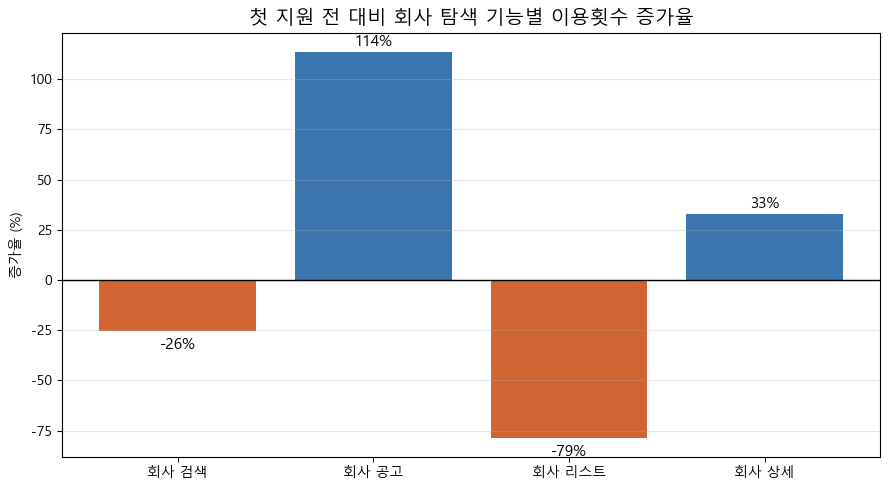

In [26]:
# =========================
# 9.1 시각화: 회사 탐색 기능별 이용횟수 증가율
# =========================

fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#3B75AF" if v >= 0 else "#D06432" for v in company_growth["증가율(%)"]]
bars = ax.bar(company_growth.index, company_growth["증가율(%)"], color=colors)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            h + 3 if h >= 0 else h - 9,
            f"{h:.0f}%", ha="center", fontsize=11)

ax.axhline(y=0, color="black", linewidth=1)
ax.set_title("첫 지원 전 대비 회사 탐색 기능별 이용횟수 증가율", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("증가율 (%)")
plt.xticks(rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 해석

지원을 기점으로 회사 탐색 방식이 **'브라우징'에서 '타기팅'으로 전환**된다는 강력한 시그널이다.

| 기능 | 지원 전후 변화 | 해석 |
|------|--------------|------|
| 회사 공고 | 약 **+110%** 증가 | 지원 후 다음 지원 후보 공고 적극 탐색 |
| 회사 상세 | 약 **+30%** 증가 | 지원 후에도 특정 회사 딥다이브 지속 |
| 회사 리스트 | 약 **-80%** 감소 | 넓은 브라우징 탐색 단계 종료 |
| 회사 검색 | 약 **-27%** 감소 | 이미 좁혀진 타겟 위주로 이동 |

> **인사이트**: 지원 완료 직후 회사 공고 페이지에 "관련 공고/유사 회사 추천" 기능을 강화하면 연속 지원율을 높일 수 있다.


## 9.2 지원 횟수 그룹별 회사 탐색 이용률

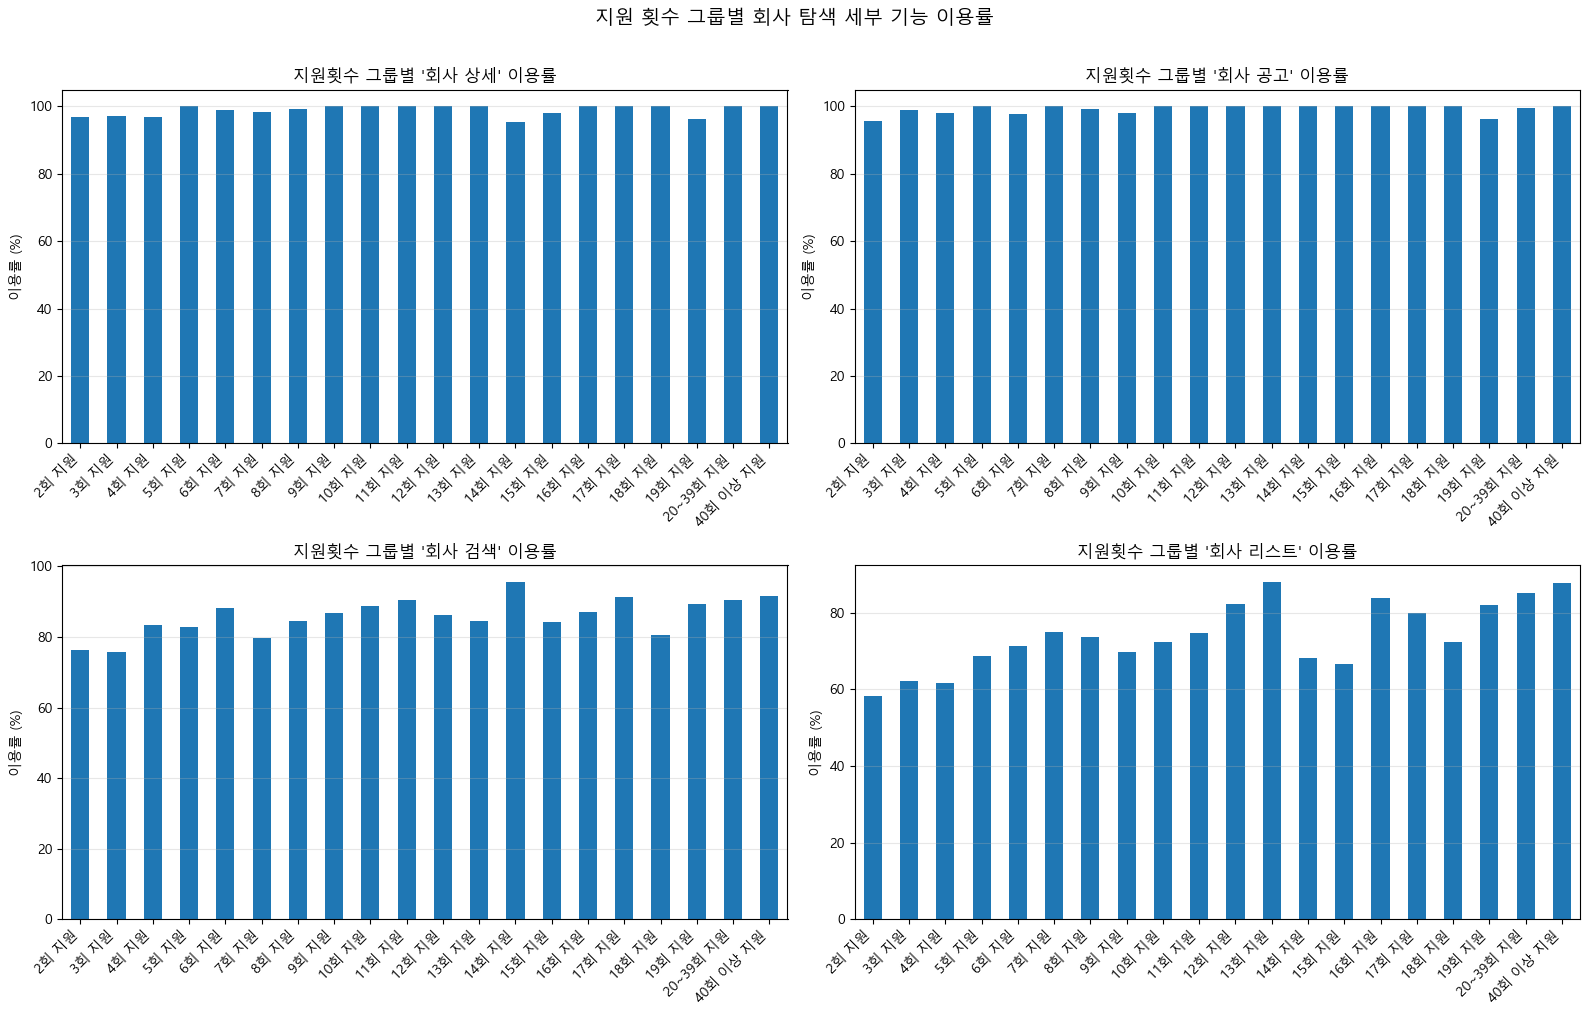

In [27]:
# =========================
# 9.2 지원횟수 그룹별 회사 탐색 이용률
# =========================

retention_uuids = set(retention_users["user_uuid"].unique())
retention_url_logs = url_log_df[url_log_df["user_uuid"].isin(retention_uuids)].copy()

# apply_count_group 병합
# url_log_df에 이미 있는 apply_total과 컬럼명이 겹치면 병합 후 apply_total_x/apply_total_y로
# 쪼개져 KeyError가 나므로, retained_apply_counts 쪽 값을 쓰기 위해 기존 컬럼을 먼저 제거한다.
retention_url_logs = retention_url_logs.drop(columns=["apply_total"], errors="ignore").merge(
    retained_apply_counts[["user_uuid","apply_count_group","apply_total"]],
    on="user_uuid", how="left"
)

company_base = retention_url_logs[
    retention_url_logs["apply_total"] >= 2
][["user_uuid","apply_count_group"]].drop_duplicates().copy()

company_cat_logs = retention_url_logs[
    (retention_url_logs["category"] == "04_회사 탐색") &
    (retention_url_logs["apply_total"] >= 2)
].copy()

company_ratio = (
    company_cat_logs
    .groupby(["apply_count_group","feature_subcategory"], observed=True)
    .agg(user_count=("user_uuid","nunique")).reset_index()
)
base_users = (
    company_base.groupby("apply_count_group", observed=True)
    .agg(total_users=("user_uuid","nunique")).reset_index()
)
company_ratio = company_ratio.merge(base_users, on="apply_count_group", how="left")
company_ratio["user_ratio"] = (company_ratio["user_count"] / company_ratio["total_users"] * 100).round(1)

pivot_df = company_ratio.pivot(index="apply_count_group", columns="feature_subcategory", values="user_ratio")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
subcats = ["회사 상세", "회사 공고", "회사 검색", "회사 리스트"]
for ax, col in zip(axes.flatten(), subcats):
    if col in pivot_df.columns:
        pivot_df[col].plot(kind="bar", ax=ax)
        ax.set_title(f"지원횟수 그룹별 '{col}' 이용률")
        ax.set_xlabel("")
        ax.set_ylabel("이용률 (%)")
        ax.grid(axis="y", alpha=0.3)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.suptitle("지원 횟수 그룹별 회사 탐색 세부 기능 이용률", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
# 10. 오퍼 및 사람/네트워크 분석

## 10.1 오퍼 행동: 지원 횟수 그룹별 이용률

**분석 목적**: 오퍼(채용 제안)는 플랫폼의 고도화된 채용 기능이다. 지원 횟수가 많은 유저일수록 오퍼 영역과의 접점이 어떻게 달라지는지 확인한다.


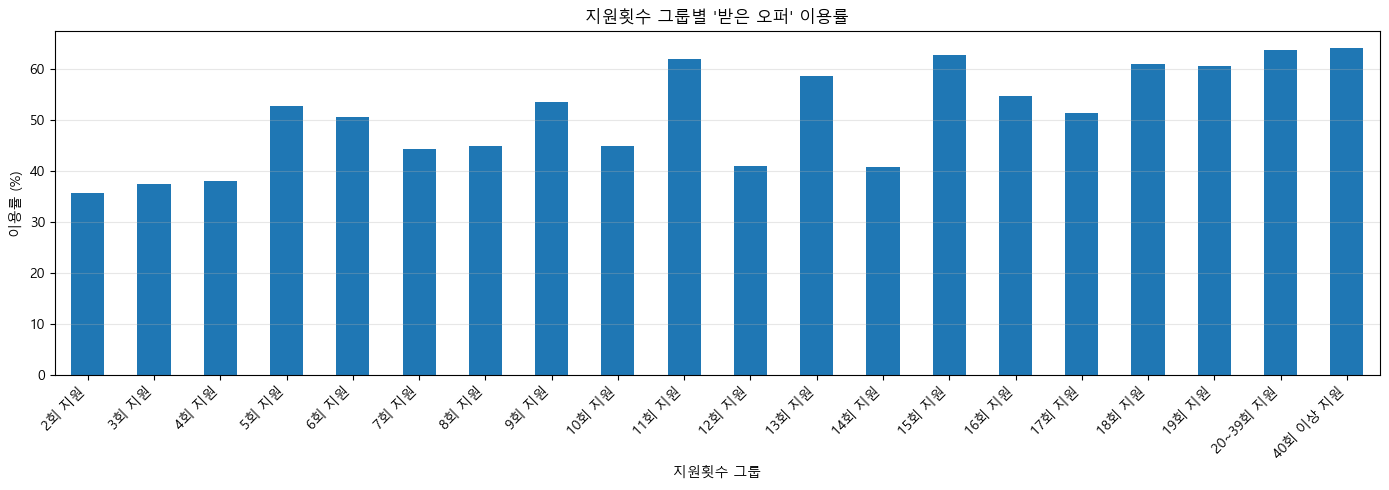

In [28]:
# =========================
# 10.1 오퍼 지원횟수 그룹별 이용률
# =========================

offer_base = retention_url_logs[retention_url_logs["apply_total"] >= 2][
    ["user_uuid","apply_count_group"]
].drop_duplicates().copy()

offer_logs = retention_url_logs[
    (retention_url_logs["category"] == "09_오퍼") &
    (retention_url_logs["apply_total"] >= 2)
].copy()

offer_ratio = (
    offer_logs
    .groupby(["apply_count_group","feature_subcategory"], observed=True)
    .agg(user_count=("user_uuid","nunique")).reset_index()
)
offer_ratio = offer_ratio.merge(
    offer_base.groupby("apply_count_group", observed=True).agg(total_users=("user_uuid","nunique")).reset_index(),
    on="apply_count_group", how="left"
)
offer_ratio["user_ratio"] = (offer_ratio["user_count"] / offer_ratio["total_users"] * 100).round(1)

# 받은 오퍼 이용률 시각화
pivot_offer = offer_ratio.pivot(index="apply_count_group", columns="feature_subcategory", values="user_ratio")

if "받은 오퍼" in pivot_offer.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    pivot_offer["받은 오퍼"].plot(kind="bar", ax=ax)
    ax.set_title("지원횟수 그룹별 '받은 오퍼' 이용률")
    ax.set_xlabel("지원횟수 그룹")
    ax.set_ylabel("이용률 (%)")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

pivot_offer


### 해석

- **받은 오퍼 이용률**: 지원 횟수가 많을수록 증가하며, 많이 지원한 유저일수록 오퍼를 받을 가능성이 높거나 오퍼 확인이 습관화되어 있다.
- **오퍼 거절/거절 작성**: 전 구간에서 1~6%로 낮아, 실제 오퍼 의사결정 단계까지 도달한 사례는 적다.
- 오퍼는 채용 프로세스의 후반부를 나타내는 기능으로, 지원 횟수가 쌓인 유저들에게 더 의미 있는 영역이다.


## 10.2 사람/네트워크 행동: 지원 횟수별 탐색 깊이

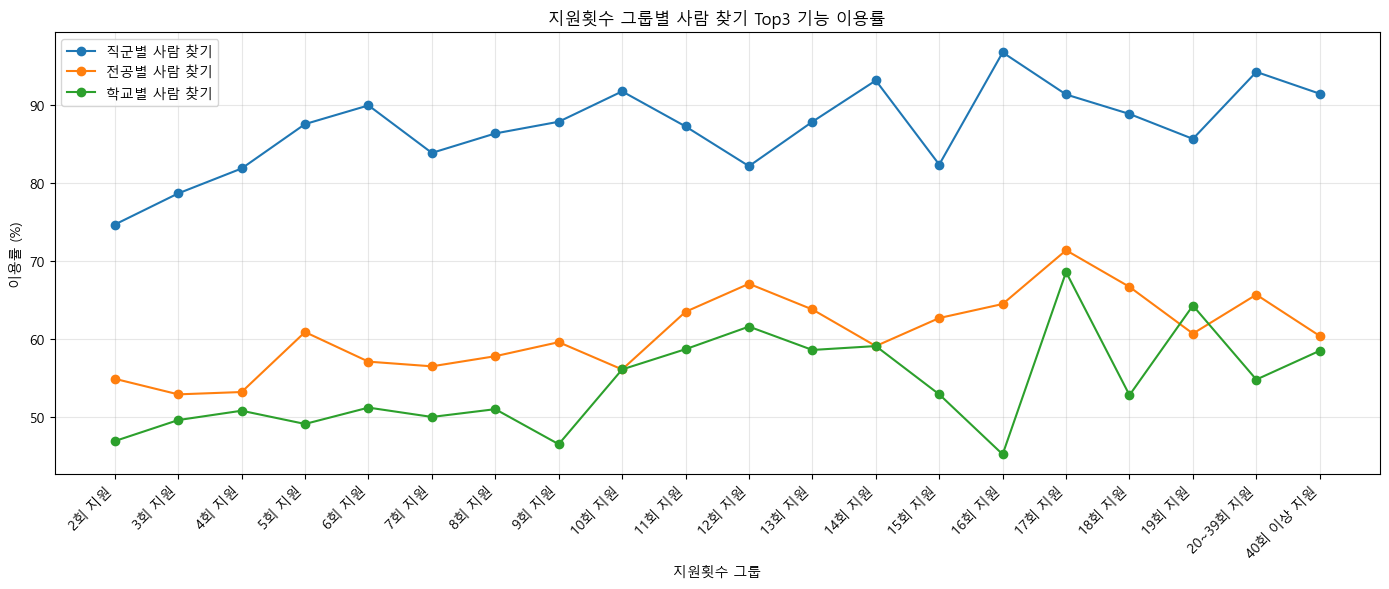

In [29]:
# =========================
# 10.2 사람/네트워크 지원횟수 그룹별 이용률
# =========================

people_base = retention_url_logs[retention_url_logs["apply_total"] >= 2][
    ["user_uuid","apply_count_group"]
].drop_duplicates().copy()

people_logs = retention_url_logs[
    (retention_url_logs["category"] == "11_사람/네트워크") &
    (retention_url_logs["apply_total"] >= 2)
].copy()

people_ratio = (
    people_logs
    .groupby(["apply_count_group","feature_subcategory"], observed=True)
    .agg(user_count=("user_uuid","nunique")).reset_index()
)
people_ratio = people_ratio.merge(
    people_base.groupby("apply_count_group", observed=True).agg(total_users=("user_uuid","nunique")).reset_index(),
    on="apply_count_group", how="left"
)
people_ratio["user_ratio"] = (people_ratio["user_count"] / people_ratio["total_users"] * 100).round(1)

# 직군별/전공별/학교별 Top3 라인 차트
top3_people = ["직군별 사람 찾기", "전공별 사람 찾기", "학교별 사람 찾기"]
people_top3_ratio = people_ratio[people_ratio["feature_subcategory"].isin(top3_people)].copy()

pivot_people = people_top3_ratio.pivot(index="apply_count_group", columns="feature_subcategory", values="user_ratio")

fig, ax = plt.subplots(figsize=(14, 6))
for col in top3_people:
    if col in pivot_people.columns:
        ax.plot(range(len(pivot_people)), pivot_people[col], marker="o", label=col)
ax.set_title("지원횟수 그룹별 사람 찾기 Top3 기능 이용률")
ax.set_xlabel("지원횟수 그룹")
ax.set_ylabel("이용률 (%)")
ax.set_xticks(range(len(pivot_people)))
ax.set_xticklabels(pivot_people.index.astype(str), rotation=45, ha="right")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 해석

- **직군별 사람 찾기**가 전 지원 횟수 구간에서 가장 높은 이용률(75~97%)을 보이며, 직군이 네트워크 탐색의 1차 기준이다.
- 지원 횟수가 늘수록 사람 찾기 이용률이 전반적으로 증가 → 지원 경험과 네트워크 탐색은 함께 성장하는 관계다.
- **사람/네트워크 기능은 핵심 기능보다는 고활동 유저의 추가 이용 시그널**로 해석해야 한다.
- 10회 이상 지원 유저에게 직군별 사람 찾기, 팔로잉/팔로워 기능을 노출하는 전략이 유효할 수 있다.


---
# 11. 프로필·이력서 행동 분석

## 분석 목적

Retention 유저가 첫 지원 이후 어떤 프로필 행동을 수행하는지 확인하고, 프로필 관리 행동과 다회 지원 간의 관계를 파악한다.

**강화 행동 정의**: URL 패턴 기준으로 `api/project/form_data/media`(포트폴리오) 및 `api/verify/experience/id/form`(경력 검증) 접근을 프로필 강화 행동으로 정의한다.

## 11.1 프로필 주요 조회 행동


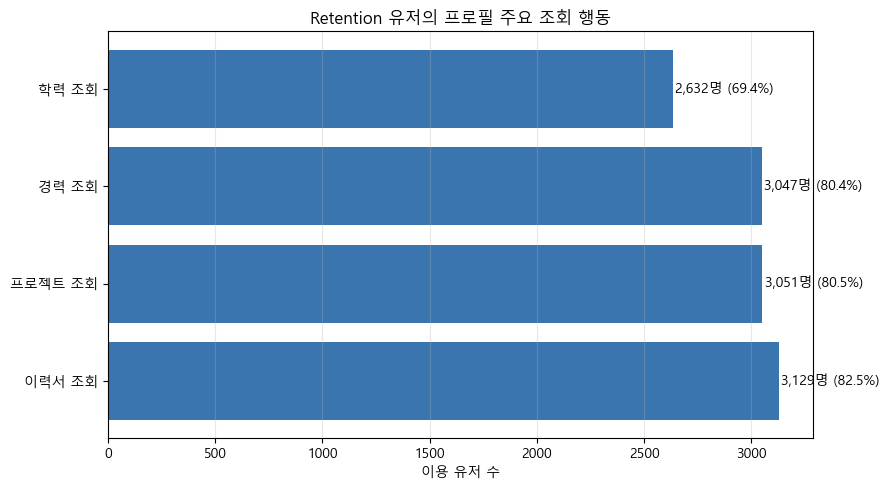

In [30]:
# =========================
# 11.1 프로필 조회 행동 이용 유저 수
# =========================

profile_subcats = ["이력서 조회", "경력 조회", "프로젝트 조회", "학력 조회"]

profile_logs = retention_url_logs[
    retention_url_logs["feature_subcategory"].isin(profile_subcats)
].copy()

profile_user_cnt = (
    profile_logs
    .groupby("feature_subcategory", as_index=False)
    .agg(user_count=("user_uuid","nunique"))
)
profile_user_cnt["ratio"] = (profile_user_cnt["user_count"] / len(retention_uuids) * 100).round(1)
profile_user_cnt = profile_user_cnt.sort_values("user_count", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(profile_user_cnt["feature_subcategory"], profile_user_cnt["user_count"], color="#3B75AF")
for i, (cnt, ratio) in enumerate(zip(profile_user_cnt["user_count"], profile_user_cnt["ratio"])):
    ax.text(cnt + 10, i, f"{cnt:,}명 ({ratio:.1f}%)", va="center")
ax.set_title("Retention 유저의 프로필 주요 조회 행동")
ax.set_xlabel("이용 유저 수")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

profile_user_cnt


### 해석

| 행동 | 유저 수 | 비율 |
|------|---------|------|
| 이력서 조회 | 2,186 | 57.7% |
| 경력 조회 | 1,371 | 36.2% |
| 프로젝트 조회 | 1,237 | 32.6% |
| 학력 조회 | 620 | 16.4% |

- Retention 유저의 절반 이상이 이력서를 조회하며, 경력·프로젝트 조회도 30% 이상으로 높게 나타난다.
- **지원 이후 가장 많이 확인하는 영역은 이력서·경력·프로젝트**로, 자신의 프로필을 지속적으로 점검하는 경향이 있다.


## 11.2 지원 횟수와 프로필 강화 행동

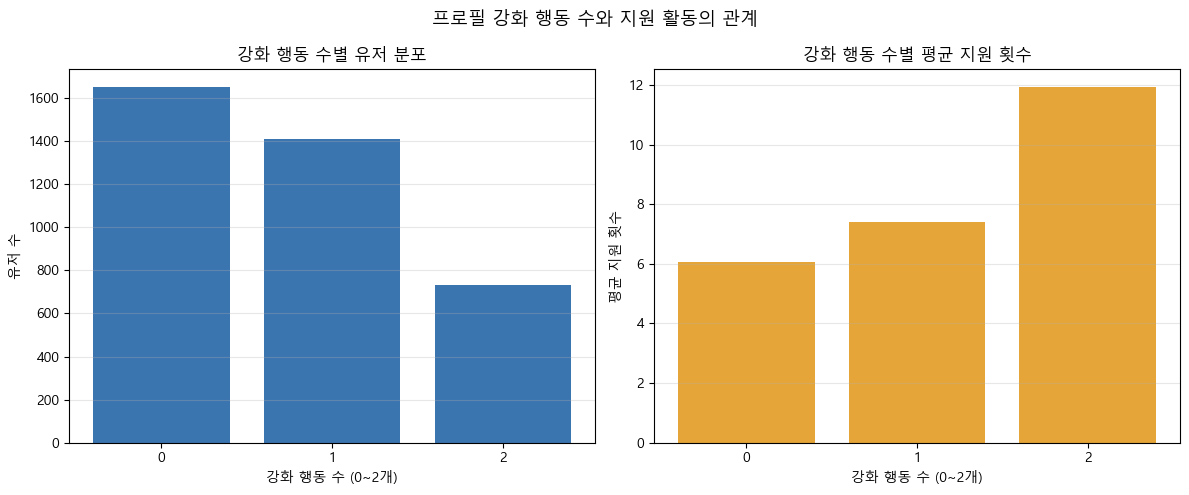

In [31]:
# =========================
# 11.2 프로필 강화 행동 (포트폴리오 / 경력검증) 분석
# =========================

profile_enhance_urls = [
    "api/project/form_data/media",
    "api/verify/experience/id/form"
]

enhance_logs = url_log_df[url_log_df["url_path"].str.contains(
    "|".join(["api/project/form_data", "api/verify/experience"]), na=False
)].copy()

enhance_logs = enhance_logs[enhance_logs["user_uuid"].isin(retention_uuids)]

enhance_per_user = (
    enhance_logs
    .groupby("user_uuid")["url_path"]
    .apply(lambda x:
           (1 if x.str.contains("api/project/form_data", na=False).any() else 0) +
           (1 if x.str.contains("api/verify/experience", na=False).any() else 0))
    .reset_index(name="enhance_cnt")
)

enhance_join = retained_apply_counts[["user_uuid","apply_total","apply_count_group"]].merge(
    enhance_per_user, on="user_uuid", how="left"
)
enhance_join["enhance_cnt"] = enhance_join["enhance_cnt"].fillna(0).astype(int)

enhance_summary = (
    enhance_join
    .groupby("enhance_cnt", as_index=False)
    .agg(user_count=("user_uuid","nunique"), avg_apply=("apply_total","mean"), median_apply=("apply_total","median"))
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(enhance_summary["enhance_cnt"].astype(str), enhance_summary["user_count"], color="#3B75AF")
axes[0].set_title("강화 행동 수별 유저 분포")
axes[0].set_xlabel("강화 행동 수 (0~2개)")
axes[0].set_ylabel("유저 수")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(enhance_summary["enhance_cnt"].astype(str), enhance_summary["avg_apply"], color="#E5A538")
axes[1].set_title("강화 행동 수별 평균 지원 횟수")
axes[1].set_xlabel("강화 행동 수 (0~2개)")
axes[1].set_ylabel("평균 지원 횟수")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("프로필 강화 행동 수와 지원 활동의 관계", fontsize=13)
plt.tight_layout()
plt.show()

enhance_summary


### 해석

| 강화 행동 수 | 유저 수 | 평균 지원 수 | 중앙값 |
|------------|---------|------------|-------|
| 0개 | 1,650 | 6.06 | 2 |
| 1개 | 1,407 | 7.39 | 4 |
| 2개 | 734 | 11.93 | 6 |

- **강화 행동이 많을수록 평균 지원 수가 증가**하며, 2개를 모두 수행한 유저는 평균 지원 수가 약 2배 수준이다.
- 강화 행동 유저의 **85%는 첫 지원 이전에 포트폴리오 또는 경력검증 행동을 수행**하였다.
- 중앙값 기준 강화 행동은 첫 지원보다 약 2일 먼저 발생 → 지원 전 프로필 점검 패턴이 우세함.

> **인사이트**: 포트폴리오/경력검증 완성도를 높이도록 가이드하는 온보딩 기능이 다회 지원 유도에 효과적일 수 있다.


---
# 12. 종합 인사이트

## 12.1 핵심 발견

### 지원이라는 이벤트가 플랫폼 이용 행태를 전반적으로 바꾼다

| 구분 | 지원 전 | 지원 후 |
|------|--------|--------|
| 회사 탐색 방식 | 리스트·검색 위주 (넓은 브라우징) | 공고·상세 위주 (타기팅 딥다이브) |
| 사람 찾기 | 전공별·학교별·직군별 폭넓게 탐색 | 급감 (목적 달성 후 감소) |
| 오퍼 | 받은 오퍼 중심 (passive) | 지원 횟수 증가와 함께 점진적 활성화 |
| 프로필 관리 | 강화 행동 수행 (지원 전 약 85%) | 이력서·경력·프로젝트 지속 점검 |

## 12.2 Quality User의 특징

1. **지원 횟수 증가 = 플랫폼 활용 깊이 증가**  
   지원 횟수가 많을수록 회사 탐색·사람 찾기·오퍼 이용률이 전반적으로 높아진다.

2. **회사 탐색이 핵심 기능**  
   회사 상세·공고 이용률은 지원 횟수와 무관하게 95~100%로 포화 상태다. 이 두 기능은 플랫폼의 필수 탐색 경로(baseline behavior)다.

3. **프로필 강화 → 더 많은 지원으로 이어진다**  
   포트폴리오·경력검증을 수행한 유저는 평균 지원 수가 유의미하게 높다.

4. **Day 1~7 Retention이 장기 재방문의 분기점**  
   Classic Retention 곡선 분석에서 첫 주 이내 재방문 여부가 장기 사용자 여부를 결정하는 주요 요인으로 보인다.

## 12.3 서비스 개선 시사점

| 우선순위 | 액션 | 근거 |
|---------|------|------|
| ★★★ | 지원 완료 직후 다음 추천 공고 강화 | 지원 후 회사 공고 이용 +110% |
| ★★★ | 회사 상세 페이지에 관련 공고·유사 회사 노출 | 회사 상세 지원 전후 이용 지속 |
| ★★ | 10회 이상 지원 유저에게 직군별 사람 찾기 노출 | 고활동 유저의 네트워크 탐색 증가 패턴 |
| ★★ | 포트폴리오·경력검증 완성 온보딩 가이드 | 강화 행동 수행 유저의 다회 지원율 2배 |
| ★ | 가입 step1→step2 이탈 구간 UX 개선 | 퍼널 최대 이탈 구간 |

## 12.4 추가 분석 제안

- 합격/불합격 결과 URL 경험률과 지원 지속성의 관계 분석
- 지원 공백 기간 구간별 재지원 패턴 분석
- 커뮤니티/콘텐츠(12번 카테고리) 행동과 지원 활동의 관계
- 코호트별(가입 월, 직군) 리텐션 비교 분석


---
# Appendix

## A. 지원 간 공백 분석

지원 이력에서 N번째 → N+1번째 지원 사이의 공백 기간을 분석하여, 지원 중단과 재시작 패턴을 파악한다.


In [32]:
# =========================
# Appendix A. 지원 간 공백 분포
# =========================
# (retained_apply_counts 및 application_history가 존재할 때 실행)

CACHE_NAME = "application_gaps"
# 예전 버전 코드로 만들어진 캐시(예: gap_days 대신 gap_days_from_prev)를 걸러내기 위해
# 이번 코드가 실제로 만드는 컬럼명을 required_cols로 검증한다.
REQUIRED_GAP_COLS = ["from_apply_time", "to_apply_time", "gap_days"]

if cache_exists(CACHE_NAME, required_cols=REQUIRED_GAP_COLS) and not REFRESH_CACHE:
    application_gaps = load_cache(CACHE_NAME)
    application_gaps = fix_datetime_cols(application_gaps, ["from_apply_time","to_apply_time","first_apply_time"])
else:
    # application_history가 필요함 (8.1 섹션 선행 실행 필요)
    try:
        ah = application_history.sort_values(["user_uuid","apply_time"]).reset_index(drop=True)
        ah["apply_order"] = ah.groupby("user_uuid").cumcount() + 1
        ah["prev_apply_time"] = ah.groupby("user_uuid")["apply_time"].shift(1)
        ah["gap_days"] = (ah["apply_time"] - ah["prev_apply_time"]).dt.total_seconds() / 86400

        application_gaps = ah[ah["prev_apply_time"].notna()].rename(
            columns={"prev_apply_time":"from_apply_time","apply_time":"to_apply_time",
                     "apply_order":"to_apply_order"}
        ).copy()
        save_cache(application_gaps, CACHE_NAME)
    except NameError:
        print("application_history가 없습니다. 섹션 8.1을 먼저 실행하세요.")
        application_gaps = None

if application_gaps is not None:
    def gap_group(d):
        if d < 1:    return "1일 미만"
        elif d < 7:  return "1~7일"
        elif d < 30: return "7~30일"
        else:        return "30일 이상"

    gap_order = ["1일 미만","1~7일","7~30일","30일 이상"]
    application_gaps["gap_group"] = pd.Categorical(
        application_gaps["gap_days"].apply(gap_group), categories=gap_order, ordered=True
    )

    gap_summary = (
        application_gaps.groupby("gap_group", observed=True, as_index=False)
        .agg(gap_count=("gap_days","count"), user_count=("user_uuid","nunique"),
             avg_gap=("gap_days","mean"), median_gap=("gap_days","median"))
    )
    gap_summary["gap_ratio"] = (gap_summary["gap_count"] / len(application_gaps) * 100).round(1)

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(gap_summary["gap_group"].astype(str), gap_summary["gap_count"], color="#3B75AF")
    for bar, ratio in zip(bars, gap_summary["gap_ratio"]):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f"{int(h):,}건\n({ratio:.1f}%)",
                ha="center", va="bottom")
    ax.set_title("지원 간 공백 구간별 분포")
    ax.set_ylabel("지원 간 공백 발생 횟수")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(gap_summary)


application_history가 없습니다. 섹션 8.1을 먼저 실행하세요.


## B. 가입 후 기간별 행동 카테고리 히트맵

In [33]:
# =========================
# Appendix B. 가입 후 기간별 행동 히트맵
# =========================

query = signup_cte + """
, post_signup_logs AS (
    SELECT l.user_uuid, l.timestamp, l.url_path, d.done_time,
           TIMESTAMPDIFF(HOUR, d.done_time, l.timestamp) / 24 AS days_after_signup
    FROM logs l
    INNER JOIN step3_done_users d ON l.user_uuid=d.user_uuid AND l.timestamp>=d.done_time
    WHERE l.url_path NOT LIKE '%%signup%%' AND l.url_path <> 'api/timeline'
),
categorized AS (
    SELECT user_uuid, days_after_signup,
           CASE
               WHEN days_after_signup < 1  THEN '0~1일'
               WHEN days_after_signup < 7  THEN '1~7일'
               WHEN days_after_signup < 14 THEN '7~14일'
               WHEN days_after_signup < 30 THEN '14~30일'
               ELSE '30일 이상'
           END AS period_group,
           CASE
               WHEN url_path LIKE 'jobs%%' OR url_path LIKE 'api/jobs/job_title%%'
                    OR url_path LIKE 'api/search%%' OR url_path LIKE 'suggest%%' THEN '공고/검색 탐색'
               WHEN url_path LIKE 'companies%%' OR url_path LIKE 'api/companies%%' THEN '회사 탐색'
               WHEN url_path LIKE '%%bookmark%%' THEN '저장/관심표시'
               WHEN url_path LIKE '%%apply%%' OR url_path LIKE '%%apply_progress%%' THEN '지원/지원관리'
               WHEN url_path LIKE '@%%' OR url_path LIKE 'api/users%%'
                    OR url_path LIKE 'api/project%%' OR url_path LIKE 'api/verify%%' THEN '프로필/이력서'
               ELSE '기타'
           END AS behavior_category
    FROM post_signup_logs
)
SELECT period_group, behavior_category,
       COUNT(*) AS log_count, COUNT(DISTINCT user_uuid) AS user_count
FROM categorized
GROUP BY period_group, behavior_category
ORDER BY FIELD(period_group,'0~1일','1~7일','7~14일','14~30일','30일 이상'), user_count DESC;
"""

post_signup_behavior = pd.read_sql(query, engine)

heatmap_df = post_signup_behavior.pivot_table(
    index="behavior_category", columns="period_group",
    values="user_count", aggfunc="sum", fill_value=0
)
heatmap_df = heatmap_df.reindex(columns=["0~1일","1~7일","7~14일","14~30일","30일 이상"])

fig = px.imshow(heatmap_df, text_auto=True, aspect="auto",
                title="가입 후 기간별 행동 유저 수 히트맵",
                labels=dict(x="가입 후 기간", y="행동 카테고리", color="유저 수"),
                height=480)
fig.show()
